In [10]:
import requests
import pandas as pd
dias = "365"
# Buscando preços do Bitcoin dos últimos 30 dias
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {
    "vs_currency": "usd",
    "days": dias,
    "interval": "daily"
}

resposta = requests.get(url, params=params)
dados = resposta.json()

# Transformando em tabela

df = pd.DataFrame(dados["prices"], columns=["timestamp", "preco"])
df["data"] = pd.to_datetime(df["timestamp"], unit="ms")
df = df[["data", "preco"]]


print(f"\nMédia dos últimos {dias} dias: ${df['preco'].mean():,.2f}")
print(f"Máxima: ${df['preco'].max():,.2f}")
print(f"Mínima: ${df['preco'].min():,.2f}")


Média dos últimos 365 dias: $96,812.65
Máxima: $124,773.51
Mínima: $62,853.69


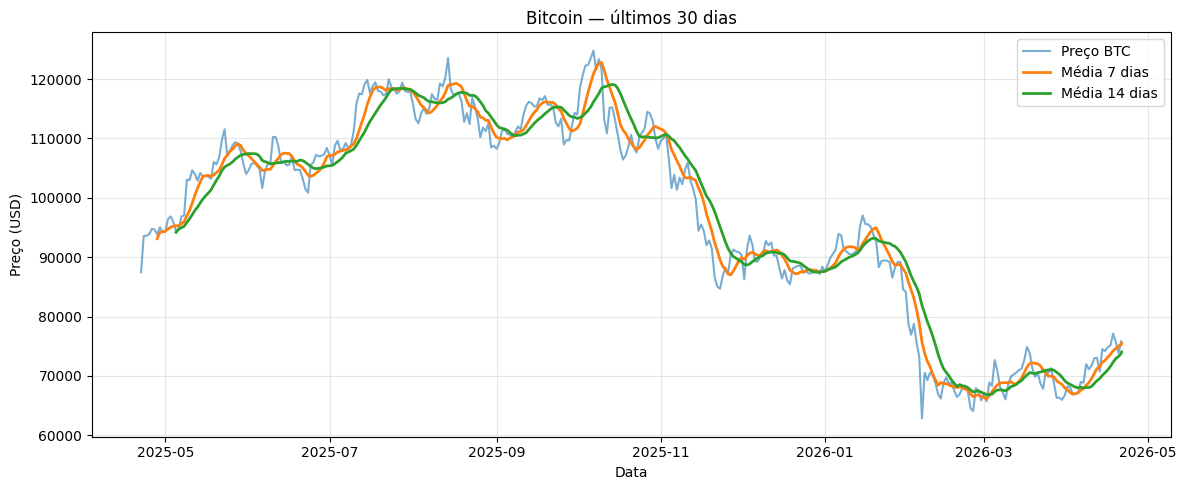

Gráfico salvo!


In [11]:
import matplotlib.pyplot as plt

# Calculando médias móveis
df["media_7d"] = df["preco"].rolling(7).mean()
df["media_14d"] = df["preco"].rolling(14).mean()

# Plotando gráfico
plt.figure(figsize=(12, 5))
plt.plot(df["data"], df["preco"], label="Preço BTC", alpha=0.6)
plt.plot(df["data"], df["media_7d"], label="Média 7 dias", linewidth=2)
plt.plot(df["data"], df["media_14d"], label="Média 14 dias", linewidth=2)
plt.title("Bitcoin — últimos 30 dias")
plt.xlabel("Data")
plt.ylabel("Preço (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig("btc_30dias.png")
plt.show()
print("Gráfico salvo!")

=== Estatísticas dos retornos diários (%) ===
Média:         -0.01%
Desvio padrão: 2.26%
Maior alta:    12.20%
Maior queda:   -14.10%

Dias positivos: 180
Dias negativos: 185


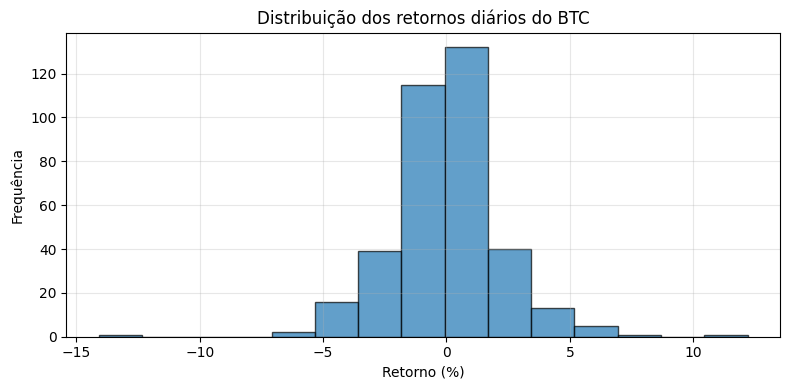

In [12]:
# Calculando retornos diários
df["retorno"] = df["preco"].pct_change() * 100

# Estatísticas dos retornos
print("=== Estatísticas dos retornos diários (%) ===")
print(f"Média:         {df['retorno'].mean():.2f}%")
print(f"Desvio padrão: {df['retorno'].std():.2f}%")
print(f"Maior alta:    {df['retorno'].max():.2f}%")
print(f"Maior queda:   {df['retorno'].min():.2f}%")

# Dias positivos vs negativos
positivos = (df["retorno"] > 0).sum()
negativos = (df["retorno"] < 0).sum()
print(f"\nDias positivos: {positivos}")
print(f"Dias negativos: {negativos}")

# Plotando distribuição dos retornos
plt.figure(figsize=(8, 4))
df["retorno"].dropna().hist(bins=15, edgecolor="black", alpha=0.7)
plt.title("Distribuição dos retornos diários do BTC")
plt.xlabel("Retorno (%)")
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Sharpe Ratio — mede retorno ajustado ao risco
# Fórmula: (retorno médio - taxa livre de risco) / desvio padrão

taxa_livre_risco = 0.0375 / 365  # ex: 2% ao ano convertido para diário (Treasury EUA)

retorno_medio = df["retorno"].mean() / 100  # convertendo % para decimal
volatilidade = df["retorno"].std() / 100

sharpe_diario = (retorno_medio - taxa_livre_risco) / volatilidade
sharpe_anual = sharpe_diario * (365 ** 0.5)  # anualizado

print("=== Sharpe Ratio ===")
print(f"Retorno médio diário: {retorno_medio*100:.4f}%")
print(f"Volatilidade diária:  {volatilidade*100:.4f}%")
print(f"Sharpe anualizado:    {sharpe_anual:.2f}")
print()

# Interpretação
if sharpe_anual > 2:
    print("Excelente — estratégia muito eficiente")
elif sharpe_anual > 1:
    print("Bom — estratégia sólida")
elif sharpe_anual > 0:
    print("Fraco — retorno não compensa bem o risco")
else:
    print("Negativo — você seria melhor em renda fixa")

=== Sharpe Ratio ===
Retorno médio diário: -0.0142%
Volatilidade diária:  2.2559%
Sharpe anualizado:    -0.21

Negativo — você seria melhor em renda fixa


=== Drawdown Máximo ===
Pior queda em relação ao pico: -49.63%
Preço no pico:   $124,773.51
Preço no fundo:  $62,853.69


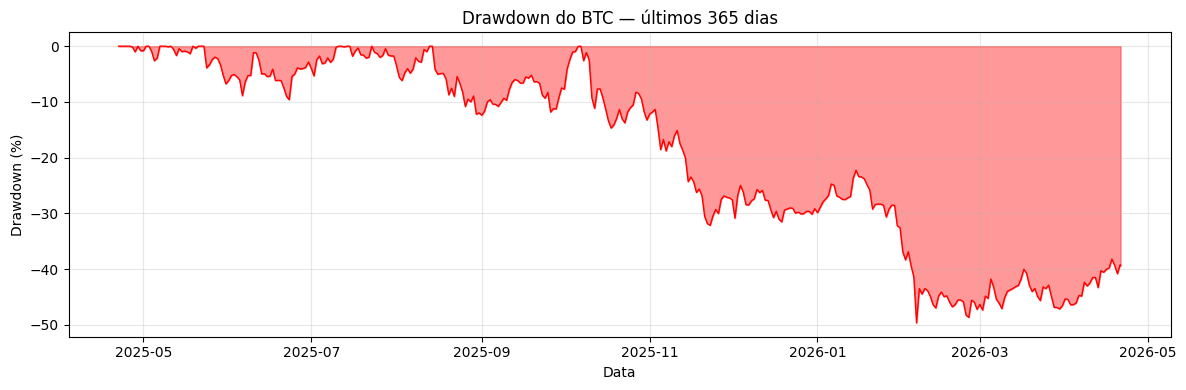

In [14]:
# Drawdown máximo — a pior sequência de perdas do período

# Calculando o pico acumulado até cada ponto
df["pico"] = df["preco"].cummax()

# Drawdown em cada dia = queda em relação ao pico anterior
df["drawdown"] = (df["preco"] - df["pico"]) / df["pico"] * 100

# Máximo drawdown do período
max_drawdown = df["drawdown"].min()

print("=== Drawdown Máximo ===")
print(f"Pior queda em relação ao pico: {max_drawdown:.2f}%")
print(f"Preço no pico:   ${df.loc[df['drawdown'].idxmin(), 'pico']:,.2f}")
print(f"Preço no fundo:  ${df.loc[df['drawdown'].idxmin(), 'preco']:,.2f}")

# Plotando
plt.figure(figsize=(12, 4))
plt.fill_between(df["data"], df["drawdown"], 0, alpha=0.4, color="red")
plt.plot(df["data"], df["drawdown"], color="red", linewidth=1)
plt.title("Drawdown do BTC — últimos 365 dias")
plt.xlabel("Data")
plt.ylabel("Drawdown (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== Resultado do Backtest (capital inicial: $1.000) ===
Estratégia médias móveis: $914.70
Buy and hold:             $865.09
Diferença:                $49.61


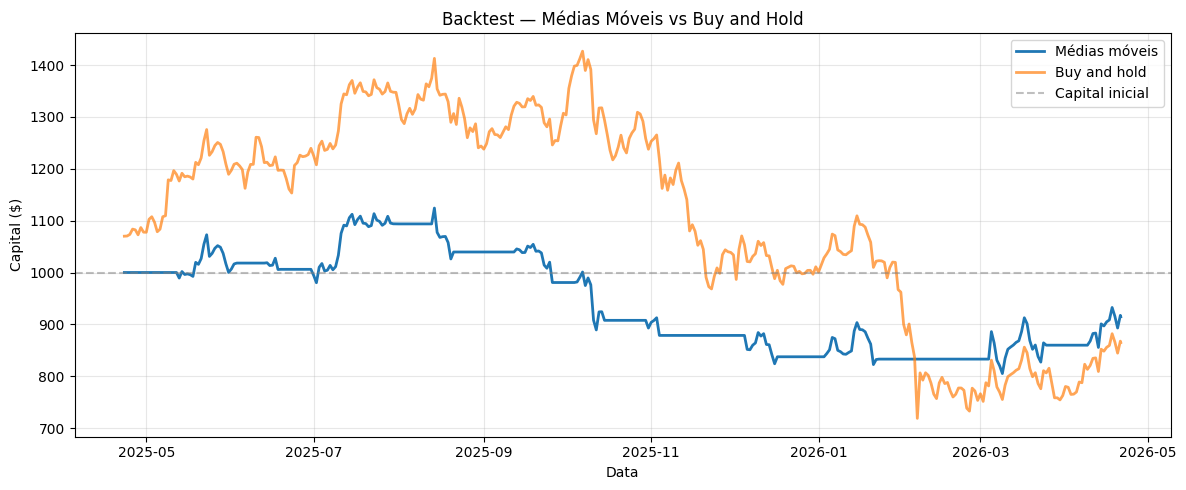

In [15]:
# Backtest simples — estratégia de cruzamento de médias móveis
# Regra: quando média 7 dias cruza acima da média 21 dias → compra
#        quando média 7 dias cruza abaixo da média 21 dias → vende

df["media_7"] = df["preco"].rolling(7).mean()
df["media_21"] = df["preco"].rolling(21).mean()

# Sinal: 1 = comprado, 0 = fora do mercado
df["sinal"] = 0
df.loc[df["media_7"] > df["media_21"], "sinal"] = 1

# Retorno da estratégia vs buy and hold
df["retorno_diario"] = df["preco"].pct_change()
df["retorno_estrategia"] = df["retorno_diario"] * df["sinal"].shift(1)

# Acumulando os retornos
df["equity_estrategia"] = (1 + df["retorno_estrategia"]).cumprod() * 1000
df["equity_buyhold"] = (1 + df["retorno_diario"]).cumprod() * 1000

# Resultados
print("=== Resultado do Backtest (capital inicial: $1.000) ===")
print(f"Estratégia médias móveis: ${df['equity_estrategia'].iloc[-1]:,.2f}")
print(f"Buy and hold:             ${df['equity_buyhold'].iloc[-1]:,.2f}")
print(f"Diferença:                ${df['equity_estrategia'].iloc[-1] - df['equity_buyhold'].iloc[-1]:,.2f}")

# Plotando
plt.figure(figsize=(12, 5))
plt.plot(df["data"], df["equity_estrategia"], label="Médias móveis", linewidth=2)
plt.plot(df["data"], df["equity_buyhold"], label="Buy and hold", linewidth=2, alpha=0.7)
plt.axhline(y=1000, color="gray", linestyle="--", alpha=0.5, label="Capital inicial")
plt.title("Backtest — Médias Móveis vs Buy and Hold")
plt.xlabel("Data")
plt.ylabel("Capital ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Backtest realista — com custos de transação e slippage

custo_por_operacao = 0.001  # 0.1% por operação (taxa típica de DEX + slippage)

# Detectando quando o sinal muda (entrada e saída)
df["mudanca_sinal"] = df["sinal"].diff().abs()
total_operacoes = int(df["mudanca_sinal"].sum())

# Aplicando custo em cada mudança de posição
df["retorno_com_custo"] = df["retorno_estrategia"]
df.loc[df["mudanca_sinal"] == 1, "retorno_com_custo"] -= custo_por_operacao

# Acumulando
df["equity_com_custo"] = (1 + df["retorno_com_custo"]).cumprod() * 1000

# Resultados
print("=== Backtest Realista (com custos) ===")
print(f"Total de operações:       {total_operacoes}")
print(f"Custo por operação:       0.10%")
print(f"Custo total estimado:     {total_operacoes * 0.1:.2f}%")
print()
print(f"Estratégia sem custos:    ${df['equity_estrategia'].iloc[-1]:,.2f}")
print(f"Estratégia com custos:    ${df['equity_com_custo'].iloc[-1]:,.2f}")
print(f"Buy and hold:             ${df['equity_buyhold'].iloc[-1]:,.2f}")
print(f"Impacto dos custos:       ${df['equity_estrategia'].iloc[-1] - df['equity_com_custo'].iloc[-1]:,.2f}")

# Plotando
plt.figure(figsize=(12, 5))
plt.plot(df["data"], df["equity_com_custo"], label="Com custos", linewidth=2)
plt.plot(df["data"], df["equity_estrategia"], label="Sem custos", linewidth=2, linestyle="--", alpha=0.7)
plt.plot(df["data"], df["equity_buyhold"], label="Buy and hold", linewidth=2, alpha=0.7)
plt.axhline(y=1000, color="gray", linestyle="--", alpha=0.5, label="Capital inicial")
plt.title("Impacto dos custos de transação na estratégia")
plt.xlabel("Data")
plt.ylabel("Capital ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [1]:
import requests
import json

url = "https://gamma-api.polymarket.com/markets"
params = {
    "active": "true",
    "closed": "false",
    "limit": 20,
    "order": "volume",
    "ascending": "false"
}

resposta = requests.get(url, params=params)
dados = resposta.json()

print("=== Mercados com Probabilidades ===\n")
for mercado in dados:
    volume = float(mercado.get('volume', 0) or 0)
    end_date = mercado.get('endDate', '')[:10]
    question = mercado.get('question', 'N/A')

    # Convertendo strings para listas
    try:
        outcomes = json.loads(mercado.get('outcomePrices', '[]'))
        outcomes_labels = json.loads(mercado.get('outcomes', '[]'))
    except:
        outcomes = []
        outcomes_labels = []

    if volume > 1000:
        print(f"Pergunta:   {question}")
        print(f"Volume:     ${volume:,.2f}")
        print(f"Encerra em: {end_date}")

        if outcomes and outcomes_labels:
            for label, price in zip(outcomes_labels, outcomes):
                prob = float(price) * 100
                print(f"  {label}: {prob:.1f}%")

        print("-" * 60)

=== Mercados com Probabilidades ===

Pergunta:   Will the highest temperature in Miami be 92°F or higher on April 20?
Volume:     $9,998.27
Encerra em: 2026-04-20
  Yes: 0.1%
  No: 100.0%
------------------------------------------------------------
Pergunta:   Will the Audemars Piguet Index hit $44,000 (HIGH) by April 30?
Volume:     $9,994.68
Encerra em: 2026-04-30
  Yes: 1.7%
  No: 98.3%
------------------------------------------------------------
Pergunta:   Will Juan Daniel Oviedo win the 1st round of the 2026 Colombian presidential election?
Volume:     $99,847.65
Encerra em: 2026-05-31
  Yes: 0.1%
  No: 99.9%
------------------------------------------------------------
Pergunta:   Will Ken McFeeters win the 2026 Alabama Governor Republican primary election?
Volume:     $9,983.04
Encerra em: 2026-05-19
  Yes: 0.8%
  No: 99.2%
------------------------------------------------------------
Pergunta:   Will Russia invade another country in 2026?
Volume:     $99,813.96
Encerra em: 2026-